
# DA6002W Reinforcement Learning
## Gymnasium interface, Monte Carlo control in Blackjack, and SARSA in Cliff Walking

### Learning outcomes

By the end of this tutorial, you should be able to:

1. create, inspect, reset, step, render, seed, and close a Gymnasium environment;
2. interpret Gymnasium's `(observation, reward, terminated, truncated, info)` interface;
3. implement **on-policy first-visit Monte Carlo control** for Blackjack;
4. implement **SARSA**, an on-policy TD control method, for Cliff Walking; and
5. modify SARSA into **Q-learning** as an independent exercise.

> **Run rule:** execute the cells from top to bottom. Fixed random seeds make the demonstration reproducible, although exact learning curves can still differ slightly across library versions.



### Overview

|Topic | Main question |
|---|---|
| Gymnasium interface | How does an agent communicate with an environment? |
| MC control: Blackjack | How do complete episode returns improve a policy? |
| SARSA: Cliff Walking | How can we update after every transition? |
| Q-learning TO DO | What changes when the TD target becomes greedy? |

### Notation used

- $S_t$: state at time $t$
- $A_t$: action at time $t$
- $R_{t+1}$: reward received after taking $A_t$
- $\gamma\in[0,1]$: discount factor
- $\alpha\in(0,1]$: learning rate
- $\epsilon$: exploration probability in an $\epsilon$-greedy policy
- $G_t$: return from time $t$
- $q_\pi(s,a)$: action value under policy $\pi$
- $Q(s,a)$: current tabular estimate of an action value




## 0. Setup

This cell installs missing packages only. In a managed laboratory installation, the packages should already be available.


In [54]:

import importlib.util
import os
import subprocess
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

required = {
    "gymnasium": "gymnasium[toy-text]>=1.0,<2.0",
    "numpy": "numpy>=1.24",
    "matplotlib": "matplotlib>=3.7",
}
missing = [package for module, package in required.items()
           if importlib.util.find_spec(module) is None]

if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All required packages are already installed.")


All required packages are already installed.


In [55]:

from collections import defaultdict

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

SEED = 7
np.set_printoptions(precision=3, suppress=True)

print("Python version    :", sys.version.split()[0])
print("Gymnasium version :", gym.__version__)
print("NumPy version     :", np.__version__)
print("Random seed       :", SEED)


Python version    : 3.12.13
Gymnasium version : 1.3.0
NumPy version     : 2.0.2
Random seed       : 7



# Part I - The Gymnasium environment and interface

Gymnasium represents an environment (click for more details [here](https://gymnasium.farama.org/api/env/)) as an object with two spaces:

- `observation_space`: all valid observations $S_t$;
- `action_space`: all valid actions $A_t$.

The core interaction is:

```python
observation, info = env.reset()
next_observation, reward, terminated, truncated, info = env.step(action)
```

The environment does **not** select the action. The agent (our code) selects it and passes it to `step`.



## 1. Create and inspect an environment

We first use `CliffWalking-v1` because it has a compact text renderer. `render_mode` must be selected when the environment is created.


In [56]:

demo_env = gym.make("CliffWalking-v1", render_mode="ansi")

print("Environment object:", demo_env)
print("Environment ID    :", demo_env.spec.id)
print("Metadata          :", demo_env.metadata)
print("Observation space :", demo_env.observation_space)
print("Action space      :", demo_env.action_space)
print("Number of states  :", demo_env.observation_space.n)
print("Number of actions :", demo_env.action_space.n)
print("Action meanings   : 0=UP, 1=RIGHT, 2=DOWN, 3=LEFT")


Environment object: <OrderEnforcing<PassiveEnvChecker<CliffWalkingEnv<CliffWalking-v1>>>>
Environment ID    : CliffWalking-v1
Metadata          : {'render_modes': ['human', 'rgb_array', 'ansi'], 'render_fps': 4}
Observation space : Discrete(48)
Action space      : Discrete(4)
Number of states  : 48
Number of actions : 4
Action meanings   : 0=UP, 1=RIGHT, 2=DOWN, 3=LEFT



### Read the spaces

`Discrete(48)` means that observations are integers $0,1,\ldots,47$. The grid has 4 rows and 12 columns, and Gymnasium encodes a location as


$s = 12 \times \text{row} + \text{column}$.


`Discrete(4)` means that actions are integers $0,1,2,3$. Sampling from the action space is useful for exploration and interface testing.


In [58]:

demo_env.action_space.seed(SEED)
sampled_actions = [int(demo_env.action_space.sample()) for _ in range(8)]

print("Eight valid sampled actions:", sampled_actions)
print("Does state 36 belong to observation_space?", demo_env.observation_space.contains(36))
print("Does action 4 belong to action_space?", demo_env.action_space.contains(4))


Eight valid sampled actions: [3, 2, 2, 3, 2, 3, 3, 0]
Does state 36 belong to observation_space? True
Does action 4 belong to action_space? False



## 2. Reset, render, and take one step

`reset(seed=...)` starts a new episode and returns **two** objects. `step(action)` returns **five** objects.


In [59]:

observation, info = demo_env.reset(seed=SEED)

print("reset() observation:", observation)
print("reset() info       :", info)
print("Decoded grid cell  :", divmod(observation, 12), "= (row, column)")
print("Rendered state:\n")
print(demo_env.render())


reset() observation: 36
reset() info       : {'prob': 1}
Decoded grid cell  : (3, 0) = (row, column)
Rendered state:

o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  C  C  C  C  C  C  C  C  C  C  T




In [60]:

action = 0  # UP
next_observation, reward, terminated, truncated, info = demo_env.step(action)

print("Action             :", action, "(UP)")
print("Next observation   :", next_observation)
print("Reward R_(t+1)     :", reward)
print("Terminated         :", terminated)
print("Truncated          :", truncated)
print("Info               :", info)
print("Rendered next state:\n")
print(demo_env.render())


Action             : 0 (UP)
Next observation   : 24
Reward R_(t+1)     : -1
Terminated         : False
Truncated          : False
Info               : {'prob': 1.0}
Rendered next state:

o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  o  o  o  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  T





### `terminated` is not the same as `truncated`

| Flag | Meaning | Example |
|---|---|---|
| `terminated=True` | a terminal state defined by the MDP was reached | reaching the goal |
| `truncated=True` | an external limit ended the episode | a time-limit wrapper |

Use

```python
done = terminated or truncated
```

to decide when to reset.



## 3. A complete random episode

This short trace exposes the full interaction loop. We cap it at 15 steps because a random Cliff Walking agent may wander for a long time.


In [ ]:

observation, info = demo_env.reset(seed=SEED)
episode_return = 0.0

for t in range(15):
    action = demo_env.action_space.sample()        # random action
    next_observation, reward, terminated, truncated, info = demo_env.step(action)
    episode_return += reward

    print(
        f"t={t:02d} | S_t={observation:2d} | A_t={action} | "
        f"R_(t+1)={reward:6.1f} | S_(t+1)={next_observation:2d} | "
        f"terminated={terminated} | truncated={truncated}"
    )

    observation = next_observation
    if terminated or truncated:
        print("Episode ended; reset is required before another step.")
        break
else:
    print("Demonstration stopped at the 15-step teaching cap.")

print("Accumulated reward:", episode_return)
demo_env.close()
print("Environment closed.")


t=00 | S_t=36 | A_t=0 | R_(t+1)=  -1.0 | S_(t+1)=24 | terminated=False | truncated=False
t=01 | S_t=24 | A_t=1 | R_(t+1)=  -1.0 | S_(t+1)=25 | terminated=False | truncated=False
t=02 | S_t=25 | A_t=1 | R_(t+1)=  -1.0 | S_(t+1)=26 | terminated=False | truncated=False
t=03 | S_t=26 | A_t=3 | R_(t+1)=  -1.0 | S_(t+1)=25 | terminated=False | truncated=False
t=04 | S_t=25 | A_t=3 | R_(t+1)=  -1.0 | S_(t+1)=24 | terminated=False | truncated=False
t=05 | S_t=24 | A_t=0 | R_(t+1)=  -1.0 | S_(t+1)=12 | terminated=False | truncated=False
t=06 | S_t=12 | A_t=1 | R_(t+1)=  -1.0 | S_(t+1)=13 | terminated=False | truncated=False
t=07 | S_t=13 | A_t=3 | R_(t+1)=  -1.0 | S_(t+1)=12 | terminated=False | truncated=False
t=08 | S_t=12 | A_t=0 | R_(t+1)=  -1.0 | S_(t+1)= 0 | terminated=False | truncated=False
t=09 | S_t= 0 | A_t=3 | R_(t+1)=  -1.0 | S_(t+1)= 0 | terminated=False | truncated=False
t=10 | S_t= 0 | A_t=0 | R_(t+1)=  -1.0 | S_(t+1)= 0 | terminated=False | truncated=False
t=11 | S_t= 0 | A_t=1


# Part II - Monte Carlo learning with Blackjack

Blackjack as an episodic MDP:

- **state:** player total, dealer's face-up card, and whether the player has a usable ace;
- **actions:** stick or hit;
- **terminal reward:** $+1$ win, $-1$ loss, $0$ draw.

Gymnasium uses the observation tuple


$S_t=(\text{player sum},\;\text{dealer card},\;\text{usable ace})$


and actions `0=STICK`, `1=HIT`.



## 4. Inspect Blackjack and print one episode

The simple behaviour policy below sticks on 20 or 21 and hits otherwise. It is only for understanding the environment; it is not the learned policy.


In [63]:

blackjack_demo = gym.make("Blackjack-v1", sab=True)

print("Environment       :", blackjack_demo)
print("Observation space :", blackjack_demo.observation_space)
print("Action space      :", blackjack_demo.action_space)
print("Observation       : (player_sum, dealer_face_up_card, usable_ace)")
print("Actions           : 0=STICK, 1=HIT")

state, info = blackjack_demo.reset(seed=SEED)
print("\nInitial state:", state, "| info:", info)

for t in range(20):
    action = 0 if state[0] >= 20 else 1
    next_state, reward, terminated, truncated, info = blackjack_demo.step(action)
    print(
        f"t={t:02d} | S_t={state} | A_t={action} "
        f"({'STICK' if action == 0 else 'HIT'}) | R_(t+1)={reward:+.0f} | "
        f"S_(t+1)={next_state} | terminated={terminated} | truncated={truncated}"
    )
    state = next_state
    if terminated or truncated:
        break

blackjack_demo.close()


Environment       : <OrderEnforcing<PassiveEnvChecker<BlackjackEnv<Blackjack-v1>>>>
Observation space : Tuple(Discrete(32), Discrete(11), Discrete(2))
Action space      : Discrete(2)
Observation       : (player_sum, dealer_face_up_card, usable_ace)
Actions           : 0=STICK, 1=HIT

Initial state: (19, 10, 0) | info: {}
t=00 | S_t=(19, 10, 0) | A_t=1 (HIT) | R_(t+1)=-1 | S_(t+1)=(29, 10, 0) | terminated=True | truncated=False



## 5. First-visit on-policy MC control

Monte Carlo methods wait for a complete episode and use the observed return


$G_t = \sum_{k=0}^{T-t-1}\gamma^k R_{t+k+1}$

For Blackjack, rewards occur at the end, and we use $\gamma=1$.

The first-visit estimate is


$\hat q_\pi(s,a)=\frac{G(s,a)}{N(s,a)}$

i.e. the sum of all returns observed after the first visit to state-action pair / number of first visits

We implement the same running average without storing all past returns:


$Q(s,a) \leftarrow Q(s,a)+\frac{1}{N(s,a)}\left[G_t-Q(s,a)\right]$


The behaviour policy is $\epsilon$-greedy with respect to the current $Q$. Because this same policy both generates experience and is improved, the method is **on-policy**.


In [64]:

def epsilon_greedy_action(Q, state, n_actions, epsilon, rng):
    '''Sample A_t from an epsilon-greedy policy based on Q(S_t, .).'''
    if rng.random() < epsilon:
        return int(rng.integers(n_actions))  # exploration

    action_values = Q[state]
    greedy_actions = np.flatnonzero(action_values == action_values.max())
    return int(rng.choice(greedy_actions))  # random tie-breaking


def generate_blackjack_episode(env, Q, epsilon, rng, seed = 0):
    '''Return [(S_t, A_t, R_(t+1)), ...] for one complete episode.'''
    episode = []
    state, info = env.reset(seed=seed)

    while True:
        action = epsilon_greedy_action(Q, state, env.action_space.n, epsilon, rng)
        next_state, reward, terminated, truncated, info = env.step(action)
        episode.append((state, action, reward))
        state = next_state

        if terminated or truncated:
            return episode


In [65]:

def mc_control_blackjack(num_episodes=60000, epsilon=0.10, gamma=1.0, seed=SEED):
    '''On-policy first-visit MC control using alpha=1/N(s,a).'''
    env = gym.make("Blackjack-v1", sab=True)
    env.reset(seed=seed)
    env.action_space.seed(seed)
    rng = np.random.default_rng(seed)

    n_actions = env.action_space.n
    Q = defaultdict(lambda: np.zeros(n_actions, dtype=float))
    N = defaultdict(lambda: np.zeros(n_actions, dtype=int))
    episode_rewards = np.empty(num_episodes, dtype=float)

    for episode_index in range(num_episodes):
        episode_seed = seed if episode_index == 0 else None


        episode = generate_blackjack_episode(env, Q, epsilon, rng, seed= episode_seed)
        episode_rewards[episode_index] = sum(reward for _, _, reward in episode)

        # First compute G_t for every t by moving backward through the episode.
        returns = np.empty(len(episode), dtype=float)
        G = 0.0
        for t in range(len(episode) - 1, -1, -1):
            G = episode[t][2] + gamma * G
            returns[t] = G
        # main loop
        # Then move forward: update only the FIRST occurrence of each (s, a).
        visited = set()
        for (state, action, reward), G_t in zip(episode, returns): #starts from starting of episode!
            if (state, action) in visited:
                continue # skip repeated visit in this episode
            visited.add((state, action))

            N[state][action] += 1 #for that specific state action pair
            alpha = 1.0 / N[state][action]
            Q[state][action] += alpha * (G_t - Q[state][action]) # keep track till s,a pair remains first visit and Update Q using the return from the first visit to this (state, action) pair

    env.close()
    return Q, N, episode_rewards


Q_mc, N_mc, mc_rewards = mc_control_blackjack()

print("Training episodes     :", len(mc_rewards))
print("Distinct states seen  :", len(Q_mc))
print("Mean reward, first 5k :", mc_rewards[:5_000].mean().round(3))
print("Mean reward, last 5k  :", mc_rewards[-5_000:].mean().round(3))


Training episodes     : 60000
Distinct states seen  : 280
Mean reward, first 5k : -0.143
Mean reward, last 5k  : -0.102



### Code-to-formula map

| Mathematics | Code |
|---|---|
| $S_t$ | `state` |
| $A_t$ | `action` |
| $R_{t+1}$ | `reward` or `episode[t][2]` |
| $G_t=R_{t+1}+\gamma G_{t+1}$ | `G = episode[t][2] + gamma * G` |
| $N(s,a)\leftarrow N(s,a)+1$ | `N[state][action] += 1` |
| $\alpha=1/N(s,a)$ | `alpha = 1.0 / N[state][action]` |
| $Q\leftarrow Q+\alpha(G_t-Q)$ | final update line |

**Common error:** updating a `seen` set while looping backward produces the *last-visit* sample, not the first-visit sample. That is why this implementation computes all returns backward and applies first-visit updates forward.


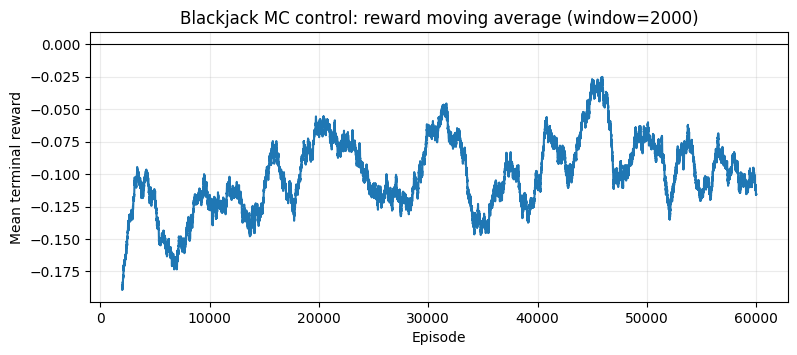

In [66]:

def moving_average(values, window): # average of values on window many values
    values = np.asarray(values, dtype=float)
    return np.convolve(values, np.ones(window) / window, mode="valid")


window = 2000
smoothed_mc = moving_average(mc_rewards, window)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(np.arange(window, len(mc_rewards) + 1), smoothed_mc, color="tab:blue")
ax.axhline(0, color="black", linewidth=0.8)
ax.set(title=f"Blackjack MC control: reward moving average (window={window})",
       xlabel="Episode", ylabel="Mean terminal reward")
ax.grid(alpha=0.25)
plt.show()


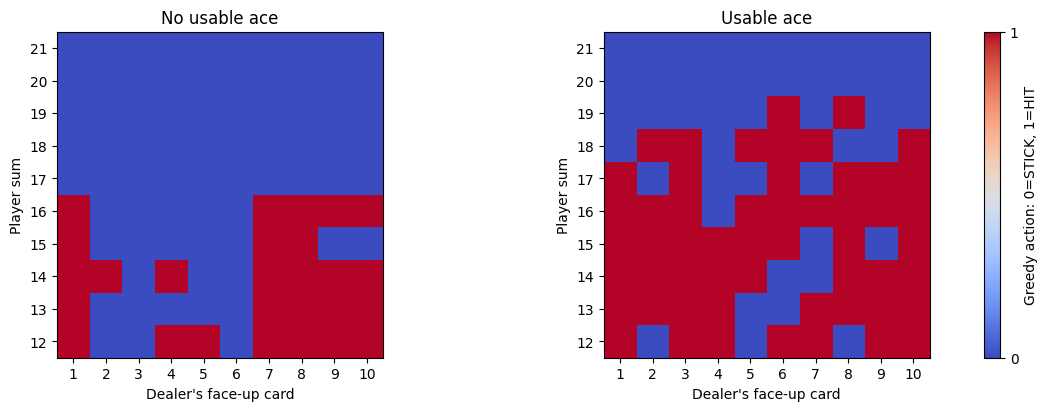

In [67]:

def blackjack_policy_grid(Q, usable_ace):
    '''Rows: player sums 12..21; columns: dealer cards 1..10.'''
    grid = np.zeros((10, 10), dtype=int)
    for row, player_sum in enumerate(range(12, 22)):
        for col, dealer_card in enumerate(range(1, 11)):
            grid[row, col] = int(np.argmax(Q[(player_sum, dealer_card, usable_ace)])) #action taken where Q value is max given this state
    return grid


fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, usable_ace in zip(axes, [False, True]):
    grid = blackjack_policy_grid(Q_mc, usable_ace)
    image = ax.imshow(grid, cmap=plt.colormaps["coolwarm"], vmin=0, vmax=1, origin="lower")
    ax.set_xticks(range(10), range(1, 11))
    ax.set_yticks(range(10), range(12, 22))
    ax.set_xlabel("Dealer's face-up card")
    ax.set_ylabel("Player sum")
    ax.set_title("Usable ace" if usable_ace else "No usable ace")

fig.colorbar(image, ax=axes, ticks=[0, 1], label="Greedy action: 0=STICK, 1=HIT")
plt.show()



## 6. Evaluate the learned greedy policy

Training uses $\epsilon>0$ to keep exploring. Evaluation uses the greedy action $\arg\max_a Q(s,a)$, so $\epsilon=0$, and does not update $Q$.


In [68]:

def evaluate_blackjack(Q, num_episodes=20000, seed=2026):
    env = gym.make("Blackjack-v1", sab=True)
    rng = np.random.default_rng(seed)
    outcomes = []

    for episode_index in range(num_episodes):
        state, info = env.reset(seed=seed if episode_index == 0 else None)
        while True:
            values = Q[state]
            greedy_actions = np.flatnonzero(values == values.max())
            action = int(rng.choice(greedy_actions))
            state, reward, terminated, truncated, info = env.step(action)
            if terminated or truncated:
                outcomes.append(reward)
                break

    env.close()
    outcomes = np.asarray(outcomes)
    return {
        "win_rate": np.mean(outcomes == 1),
        "draw_rate": np.mean(outcomes == 0),
        "loss_rate": np.mean(outcomes == -1),
        "mean_reward": outcomes.mean(),
    }


mc_evaluation = evaluate_blackjack(Q_mc)
for name, value in mc_evaluation.items():
    print(f"{name:12s}: {value:.3f}")


win_rate    : 0.429
draw_rate   : 0.091
loss_rate   : 0.480
mean_reward : -0.051



### MC checkpoint

- MC is **model-free**: no transition probabilities were supplied.
- MC waits until the episode ends because it needs $G_t$.
- First-visit MC uses at most one return sample per $(s,a)$ per episode.
- The estimate and the $\epsilon$-greedy behaviour policy improve together: this is on-policy control.



# Part III - SARSA with Cliff Walking

SARSA is an on-policy temporal-difference control method. Its name comes from the five quantities used in its update:


$S_t,\;A_t,\;R_{t+1},\;S_{t+1},\;A_{t+1}$


The update rule is


$Q(S_t,A_t) \leftarrow Q(S_t,A_t)+\alpha\left[
R_{t+1}+\gamma Q(S_{t+1},A_{t+1})-Q(S_t,A_t)
\right]$


The bracketed term is the TD error


$\delta_t=R_{t+1}+\gamma Q(S_{t+1},A_{t+1})-Q(S_t,A_t)$


Unlike MC, SARSA can update immediately after one transition; it **bootstraps** from its current estimate of the next state-action value.



## 7. Cliff Walking

A 4x12 grid, start at the lower-left, goal at the lower-right, and actions up/right/down/left.


In [69]:

cliff_env = gym.make("CliffWalking-v1")
state, info = cliff_env.reset(seed=SEED)

print("Observation space :", cliff_env.observation_space)
print("Action space      :", cliff_env.action_space)
print("Start state       :", state)
print("Goal state        :", 47)
print("Cliff cells       :", list(range(37, 47)))
print("Actions           : 0=UP, 1=RIGHT, 2=DOWN, 3=LEFT")

# Demonstrate Gymnasium's cliff transition: RIGHT from start enters the cliff.
next_state, reward, terminated, truncated, info = cliff_env.step(1)
print("\nRIGHT from start ->")
print("next_state        :", next_state, "(back at the start)")
print("reward            :", reward)
print("terminated        :", terminated)
print("truncated         :", truncated)
cliff_env.close()


Observation space : Discrete(48)
Action space      : Discrete(4)
Start state       : 36
Goal state        : 47
Cliff cells       : [37, 38, 39, 40, 41, 42, 43, 44, 45, 46]
Actions           : 0=UP, 1=RIGHT, 2=DOWN, 3=LEFT

RIGHT from start ->
next_state        : 36 (back at the start)
reward            : -100
terminated        : False
truncated         : False



## 8. Implement SARSA

Algorithm correspondence:

1. Choose $A_t$ using the current $\epsilon$-greedy policy.
2. Observe $R_{t+1},S_{t+1}$.
3. If $S_{t+1}$ is nonterminal, choose $A_{t+1}$ using that **same** policy.
4. Form the SARSA target $R_{t+1}+\gamma Q(S_{t+1},A_{t+1})$.
5. Update $Q(S_t,A_t)$, then shift to the next state-action pair.

For a terminal transition, the future value is zero, so the target is only $R_{t+1}$.


In [70]:

def sarsa_cliff_walking(
    num_episodes=500,
    alpha=0.5,
    gamma=1.0,
    epsilon=0.10,
    seed=SEED,
    max_steps=10000, # Cliff Walking: the agent may wander or loop hence use max_steps.
):
    env = gym.make("CliffWalking-v1")
    env.reset(seed=seed)
    env.action_space.seed(seed)
    rng = np.random.default_rng(seed)

    Q = np.zeros((env.observation_space.n, env.action_space.n), dtype=float)
    episode_returns = np.zeros(num_episodes, dtype=float)
    episode_lengths = np.zeros(num_episodes, dtype=int)

    for episode in range(num_episodes):
        state, info = env.reset() # continues from the seeded random sequence
        action = epsilon_greedy_action(Q, state, env.action_space.n, epsilon, rng)

        for step in range(max_steps):
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            episode_returns[episode] += reward
            episode_lengths[episode] = step + 1

            if done:
                td_target = reward  # no Q term after a terminal state
                td_error = td_target - Q[state, action]
                Q[state, action] += alpha * td_error
                break

            # A_(t+1) comes from the SAME epsilon-greedy behaviour policy.
            next_action = epsilon_greedy_action(
                Q, next_state, env.action_space.n, epsilon, rng
            )
            td_target = reward + gamma * Q[next_state, next_action] # needed to compute td_error
            td_error = td_target - Q[state, action]
            Q[state, action] += alpha * td_error # thus values are being stored

            state, action = next_state, next_action
        else:
            print(f"Warning: episode {episode} reached max_steps={max_steps}.")

    env.close()
    return Q, episode_returns, episode_lengths


Q_sarsa, sarsa_returns, sarsa_lengths = sarsa_cliff_walking()

print("Training episodes       :", len(sarsa_returns))
print("Mean return, first 50   :", sarsa_returns[:50].mean().round(1))
print("Mean return, last 50    :", sarsa_returns[-50:].mean().round(1))
print("Mean length, last 50    :", sarsa_lengths[-50:].mean().round(1))


Training episodes       : 500
Mean return, first 50   : -109.5
Mean return, last 50    : -21.3
Mean length, last 50    : 19.3



### Locate the SARSA update in code

| Formula term | Variable |
|---|---|
| $Q(S_t,A_t)$ | `Q[state, action]` |
| $R_{t+1}$ | `reward` |
| $Q(S_{t+1},A_{t+1})$ | `Q[next_state, next_action]` |
| $R_{t+1}+\gamma Q(S_{t+1},A_{t+1})$ | `td_target` |
| target minus current estimate | `td_error` |
| $Q\leftarrow Q+\alpha\delta_t$ | `Q[state, action] += alpha * td_error` |


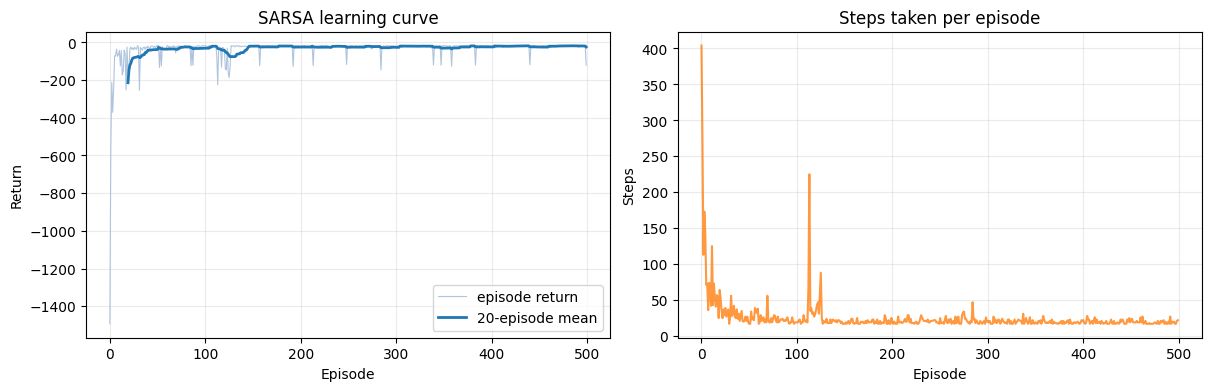

In [71]:

window = 20
smoothed_sarsa = moving_average(sarsa_returns, window)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)
axes[0].plot(sarsa_returns, color="lightsteelblue", linewidth=0.8, label="episode return")
axes[0].plot(np.arange(window - 1, len(sarsa_returns)), smoothed_sarsa,
             color="tab:blue", linewidth=2, label=f"{window}-episode mean")
axes[0].set(title="SARSA learning curve", xlabel="Episode", ylabel="Return")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(sarsa_lengths, color="tab:orange", alpha=0.8)
axes[1].set(title="Steps taken per episode", xlabel="Episode", ylabel="Steps")
axes[1].grid(alpha=0.25)
plt.show()


In [72]:

ACTION_SYMBOLS = np.array(["↑", "→", "↓", "←"])


def print_greedy_cliff_policy(Q):
    '''Print one greedy action per grid cell.'''
    grid = np.full((4, 12), " ", dtype="<U1")
    for state in range(48):
        row, col = divmod(state, 12)
        grid[row, col] = ACTION_SYMBOLS[int(np.argmax(Q[state]))]

    grid[3, 0] = "S"
    grid[3, 1:11] = "C"
    grid[3, 11] = "G"

    print("Greedy policy (S=start, C=cliff, G=goal):")
    for row in grid:
        print(" ".join(row))


print_greedy_cliff_policy(Q_sarsa)


Greedy policy (S=start, C=cliff, G=goal):
→ → → → → → → → → → → ↓
↑ ↑ ↑ → ↑ ↑ → → ↑ ↑ → ↓
↑ ↑ ↑ → ↑ → ↑ ↑ ↑ ↑ ↑ ↓
S C C C C C C C C C C G


In [73]:

def greedy_cliff_rollout(Q, max_steps=100, seed=123):
    '''Evaluate without exploration and print the visited states.'''
    env = gym.make("CliffWalking-v1")
    state, info = env.reset(seed=seed)
    path = [state]
    total_reward = 0.0

    for _ in range(max_steps):
        action = int(np.argmax(Q[state]))
        state, reward, terminated, truncated, info = env.step(action)
        path.append(state)
        total_reward += reward
        if terminated or truncated:
            break

    env.close()
    return path, total_reward, terminated or truncated


sarsa_path, sarsa_test_return, reached_goal = greedy_cliff_rollout(Q_sarsa)
print("Greedy path        :", sarsa_path)
print("Number of steps    :", len(sarsa_path) - 1)
print("Evaluation return  :", sarsa_test_return)
print("Reached goal       :", reached_goal)


Greedy path        : [36, 24, 12, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 23, 35, 47]
Number of steps    : 17
Evaluation return  : -17.0
Reached goal       : True



# Part IV - TO DO: Q-learning on Cliff Walking

Q-learning is off-policy TD control. Experience is still collected with an $\epsilon$-greedy behaviour policy, but the update uses a greedy target:


$Q(S_t,A_t) \leftarrow Q(S_t,A_t)+\alpha\left[
R_{t+1}+\gamma\max_a Q(S_{t+1},a)-Q(S_t,A_t)
\right]$


### Your task

Complete `q_learning_todo` below. Then:

1. train it using the same `num_episodes`, $\alpha$, $\gamma$, $\epsilon$, and seed as SARSA;
2. plot the return curve;
3. print the greedy policy and evaluate one greedy rollout;
4. compare the learned route and training return against SARSA; and
5. explain why Q-learning can learn the shortest greedy route while experiencing large negative rewards during $\epsilon$-greedy training.

**Do not change the environment reward function.** Remember that the terminal target has no bootstrap term.


In [ ]:

def q_learning_todo(
    num_episodes=500,
    alpha=0.5,
    gamma=1.0,
    epsilon=0.10,
    seed=SEED,
    max_steps=10_000,
):
    '''TO DO: implement tabular Q-learning for CliffWalking-v1.'''
    env = gym.make("CliffWalking-v1")
    env.reset(seed=seed)
    env.action_space.seed(seed)
    rng = np.random.default_rng(seed)

    Q = np.zeros((env.observation_space.n, env.action_space.n), dtype=float)
    episode_returns = np.zeros(num_episodes, dtype=float)

    # TODO 1: loop over episodes and call env.reset().
    # TODO 2: choose A_t with epsilon_greedy_action(...).
    # TODO 3: call env.step(A_t) and record R_(t+1).
    # TODO 4: form the terminal or nonterminal Q-learning target.
    # TODO 5: update Q(S_t, A_t), advance S_t, and stop when done.

    env.close()
    raise NotImplementedError("Complete the five TODO steps, then return Q and episode_returns.")



# Final recap

| Method | Update time | Target | Policy relationship |
|---|---|---|---|
| First-visit MC control | after a complete episode | observed $G_t$ | on-policy $\epsilon$-greedy |
| SARSA | after each transition | $R_{t+1}+\gamma Q(S_{t+1},A_{t+1})$ | on-policy |
| Q-learning | after each transition | $R_{t+1}+\gamma\max_a Q(S_{t+1},a)$ | off-policy |

### Questions to answer

1. Why must MC wait for the end of a Blackjack episode?
2. Which five samples give SARSA its name?
3. Why is `terminated` separated from `truncated`?
4. Which single expression changes when SARSA becomes Q-learning?
5. Why can the route learned by SARSA depend on $\epsilon$?
|
Always consult the Gymnasium environment documentation/version used for an assignment because API and benchmark conventions can differ from a hand-written MDP specification.
